In [ ]:
# Practice project by Zed Lyons, with advice from Chad de Vera.
# This notebook pulls the FBI NIBRS data from a pre-established private 
# postgres server for the purposes of machine-learned insights about which murders are solved and which are not.


import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle



# config for max display of columns and rows
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(100)
pl.Config.set_fmt_str_lengths(60)

today = time.strftime("%y%m%d")


In [ ]:


postgres_uri = "" #input URI of postgres server here
query = """
select 
	--nibrs_offense.csv offe
	offe.location_id, offe.incident_id as offinc_id,
	
	--nibrs_arrestee.csv arr
	arr.arrestee_id,

	--nibrs_incident.csv inc
	inc.data_year as incident_year, inc.agency_id, inc.incident_id,
	inc.cargo_theft_flag,inc.submission_date,inc.incident_date,
	inc.report_date_flag, inc.incident_hour, inc.cleared_except_id,

	--agencies.csv age (the *_rate variables are in cops per 1000 people)
	-- BE ADVISED: populations of 0 need to be made [null]
	age.yearly_agency_id,age.data_year,age.ucr_agency_name,
	age.ncic_agency_name, age.pub_agency_name,age.pub_agency_unit,
	age.state_abbr,age.agency_type_name,age.population, age.suburban_area_flag,
	age.population_group_code,age.population_group_desc,age.pop_sort_order, 
	age.male_officer, age.male_civilian, age.male_total, age.female_officer,
	age.female_civilian, age.female_total, age.officer_rate, age.employee_rate, --*_rate columns are per/1000 citizens
	age.county_name, age.msa_name,

	--nibrs_cleared_except.csv cle
	cle.cleared_except_name,

	--nibrs_weapon.csv weap
	--linking table

	--nibrs_weapon_type.csv wety
	wety.weapon_code,wety.weapon_name,
    
    --nibrs_victim_offense
    --linking table

	--nibrs_victim.csv vic
	vic.victim_id, vic.age_id, vic.age_num, vic.sex_code, 
	vic.race_id, vic.ethnicity_id, vic.resident_status_code, vic.age_range_low_num,
	vic.age_range_high_num,

	--nibrs_age age_vic
	--PLEASE NOTE: nibrs_age.csv also used for offender age
	age_vic.age_name,

	--nibrs_ethnicity.csv eth
	eth.ethnicity_name,

	--ref_race.csv rac
	rac.race_desc,

	--nibrs_victim_injury.csv viin
	--linking table

	--nibrs_injury inj
	inj.injury_name,

	--nibrs_criminal_act
	--linking table

	--nibrs_criminal_act_type cract
	cract.criminal_act_name,

	--nibrs_victim_type vity
	vity.victim_type_name,

	--nibrs_bias_motivation bim
	--linking table

	--nibrs_bias_list bil
	bil.bias_name as bias_category, bil.bias_desc,
	
	--nibrs_property.csv pro
	pro.prop_loss_id, pro.stolen_count,

	--nibrs_property_desc.csv prod
	prod.property_value, prod.date_recovered,

	--nibrs_prop_desc_type.csv prodty
	prodty.prop_desc_name,
	
	--nibrs_prop_loss_type prolty
	prolty.prop_loss_name,

	--nibrs_offender.csv der
	der.offender_id, der.age_id as klr_age_id, der.age_num as klr_age_num, der.sex_code as klr_sex_code,
	der.age_range_low_num as klr_age_range_low_num, der.age_range_high_num as klr_age_range_high_num, 
    --der.race_id as klr_race_id, der.ethnicity_id as klr_ethnicity_id,

    --nibrs_ethnicity eth_klr 
    --another LUT that's also used for the victim
    eth_klr.ethnicity_name as ethnicity_name_klr,
    
	--nibrs_age age_klr
	--this is one of two uses of nibrs_age. The other is for the victim
	age_klr.age_name as age_name_klr,

	--ref_race rac_klr
	--ref race also used for victim
    rac_klr.race_desc as race_desc_klr,

	--nibrs_victim_offender_rel.csv vor
	--linking table

	--nibrs_relationship.csv rel
	rel.relationship_name,

	--nibrs_location_type lot
	lot.location_name,

	--nibrs_suspect_using usin 
	--linking table

	--nibrs_using_list usli
	usli.suspect_using_name,
	
	
	CASE
		when arr.arrestee_id is not null then 0
		when cle.cleared_except_code in ('A','C') then 0
		else 1
		end as scot_free
		
from nibrs_offense offe 

left join nibrs_incident inc
on offe.incident_id = inc.incident_id
left join agencies age
on age.agency_id = inc.agency_id AND age.data_year = inc.data_year
left join nibrs_cleared_except cle
on cle.cleared_except_id = inc.cleared_except_id
left join nibrs_weapon weap
on weap.offense_id = offe.offense_id
left join nibrs_weapon_type wety
on weap.weapon_id = wety.weapon_id
left join nibrs_victim_offense viof
on viof.offense_id = offe.offense_id
left join nibrs_victim vic
on vic.victim_id = viof.victim_id
left join nibrs_age age_vic
on vic.age_id = age_vic.age_id
left join nibrs_ethnicity eth
on eth.ethnicity_id = vic.ethnicity_id
left join ref_race rac
on rac.race_id = vic.race_id
left join nibrs_victim_circumstances vici
on vici.victim_id = vic.victim_id
left join nibrs_circumstances circ
on circ.circumstances_id = vici.circumstances_id
left join nibrs_victim_injury viin
on viin.victim_id = vic.victim_id
left join nibrs_injury inj
on inj.injury_id = viin.injury_id
left join nibrs_criminal_act crac
on offe.offense_id = crac.offense_id
left join nibrs_criminal_act_type cract
on cract.criminal_act_id = crac.criminal_act_id
left join nibrs_victim_type vity
on vity.victim_type_id = vic.victim_type_id
left join nibrs_bias_motivation bim
on bim.offense_id = offe.offense_id
left join nibrs_bias_list bil
on bil.bias_id = bim.bias_id
left join nibrs_property pro
on pro.incident_id = inc.incident_id
left join nibrs_property_desc prod
on pro.property_id = prod.property_id
left join nibrs_prop_desc_type prodty
on prod.prop_desc_id = prodty.prop_desc_id
left join nibrs_prop_loss_type prolty
on pro.prop_loss_id = prolty.prop_loss_id
left join nibrs_offender der
on der.incident_id = offe.incident_id

left join nibrs_arrestee arr
on offe.incident_id = arr.incident_id AND der.offender_seq_num = arr.arrestee_seq_num::smallint --arrestee_seq_num is char data, irritatingly

left join ref_race rac_klr
on rac_klr.race_id = der.race_id
left join nibrs_age age_klr
on der.age_id = age_klr.age_id
left join nibrs_ethnicity eth_klr
on der.ethnicity_id = eth_klr.ethnicity_id
left join nibrs_victim_offender_rel vor
on vor.victim_id = vic.victim_id AND vor.offender_id = der.offender_id
left join nibrs_relationship rel
on rel.relationship_id = vor.relationship_id
left join nibrs_location_type lot
on lot.location_id = offe.location_id
left join nibrs_suspect_using usi
on usi.offense_id = offe.offense_id
left join nibrs_using_list usli
on usi.suspect_using_id = usli.suspect_using_id
--left join nibrs_suspected_drug sud
--on sud.property_id = pro.property_id
--left join nibrs_suspected_drug_type sdt
--on sdt.suspected_drug_type_id = sud.suspected_drug_type_id
where vity.victim_type_code in ('L', 'I');"""
#murder records occasionally duplicated as crimes against society when committed in connection with drug-dealing. We deal only in crimes against individuals/cops

murderdata = pl.read_database_uri(query,postgres_uri).unique()
murderdata_orig = murderdata

#drop unused columns
murderdata = murderdata.drop(pl.col(['arrestee_id','injury_name'])) #arrestee_id was used for scot_free but now not needed

#save an archive 
murderdata.write_parquet(f"{today}_murderdata.parquet")

In [317]:
#trouble saver cell
murderdata = pl.read_parquet(f"260224_murderdata.parquet")
#murderdata = pl.read_parquet(f"{today}_murderdata.parquet")

In [ ]:
#this section tests where the worst offenders in terms of needless data multiplication are. 
#The results of this section guide the duplication removal section below and also led to some features
# being removed from the full sql query above
queryheader = """select count(*) from nibrs_offense offe
"""
joinchunk = """left join nibrs_arrestee arr
on offe.incident_id = arr.incident_id
left join nibrs_incident inc
on offe.incident_id = inc.incident_id
left join agencies age
on age.agency_id = inc.agency_id AND age.data_year = inc.data_year
left join nibrs_cleared_except cle
on cle.cleared_except_id = inc.cleared_except_id
left join nibrs_weapon weap
on weap.offense_id = offe.offense_id
left join nibrs_weapon_type wety
on weap.weapon_id = wety.weapon_id
left join nibrs_victim vic
on vic.incident_id = offe.incident_id
left join nibrs_age age_vic
on vic.age_id = age_vic.age_id
left join nibrs_ethnicity eth
on eth.ethnicity_id = vic.ethnicity_id
left join ref_race rac
on rac.race_id = vic.race_id
left join nibrs_victim_circumstances vici
on vici.victim_id = vic.victim_id
left join nibrs_circumstances circ
on circ.circumstances_id = vici.circumstances_id
left join nibrs_victim_injury viin
on viin.victim_id = vic.victim_id
left join nibrs_injury inj
on inj.injury_id = viin.injury_id
left join nibrs_criminal_act crac
on offe.offense_id = crac.offense_id
left join nibrs_criminal_act_type cract
on cract.criminal_act_id = crac.criminal_act_id
left join nibrs_victim_type vity
on vity.victim_type_id = vic.victim_type_id
left join nibrs_bias_motivation bim
on bim.offense_id = offe.offense_id
left join nibrs_bias_list bil
on bil.bias_id = bim.bias_id
left join nibrs_property pro
on pro.incident_id = inc.incident_id
left join nibrs_property_desc prod
on pro.property_id = prod.property_id
left join nibrs_prop_desc_type prodty
on prod.prop_desc_id = prodty.prop_desc_id
left join nibrs_prop_loss_type prolty
on pro.prop_loss_id = prolty.prop_loss_id
left join nibrs_offender der
on der.incident_id = offe.incident_id
left join nibrs_age age_klr
on der.age_id = age_klr.age_id
left join nibrs_victim_offender_rel vor 
on vor.victim_id = vic.victim_id AND vor.offender_id = der.offender_id
left join nibrs_relationship rel
on rel.relationship_id = vor.relationship_id
left join nibrs_location_type lot
on lot.location_id = offe.location_id
left join nibrs_suspect_using usi
on usi.offense_id = offe.offense_id
left join nibrs_using_list usli
on usi.suspect_using_id = usli.suspect_using_id
left join nibrs_suspected_drug sud
on sud.property_id = pro.property_id
left join nibrs_suspected_drug_type sdt
on sdt.suspected_drug_type_id = sud.suspected_drug_type_id"""

'''
joinchunk="""left join nibrs_victim vic
on vic.incident_id = offe.incident_id
left join nibrs_offender der
on der.incident_id = offe.incident_id
"""
'''

tableandfactor = []
sizebeforeadding = 1064
iterquery = queryheader
joinslist = joinchunk.split("left")
joinslist.pop(0)

for join in joinslist:
    iterquery = iterquery + "left" + join
    sizeafteradding = pl.read_database_uri(iterquery+';',postgres_uri)[0,0]
    ratiolarger = sizeafteradding/sizebeforeadding
    sizebeforeadding = sizeafteradding
    tableandfactor.append((join.split(' ')[2],ratiolarger))
    print(join.split(' ')[2],ratiolarger,sizeafteradding)

## We need to address record duplication due to prop_loss_name permutations.
Whenever a crime involves more than one type of property_loss (or property, for that matter), a new row is created for every prop_loss associated with the crime.
Instead, we will create dummy columns that contain a (lossy) component of this info.

In [318]:

# Any records of burnt or damaged property rolled into a 'prop_destruction' column
destroyedpropertyCDE = murderdata.select(pl.col(['incident_id','prop_desc_name','prop_loss_name'])).unique()
destroyedpropertyCDE = destroyedpropertyCDE.with_columns(
    pl.when(  pl.col('prop_loss_name').is_in(['Destroyed/Damaged/Vandalized','Burned'])).then(1).when(pl.col('prop_loss_name').is_null()) .then(None).otherwise(0).alias('prop_destruction')
)
destroyedpropertyCDE = destroyedpropertyCDE.group_by('incident_id').agg(pl.col('prop_destruction').sum()) 

# roll seized contraband into 'taken_by_cops' column
seizedpropertyCDE = murderdata.select(pl.col(['incident_id','prop_desc_name','prop_loss_name'])).unique()
seizedpropertyCDE = seizedpropertyCDE.with_columns(
    pl.when(pl.col('prop_loss_name')=='Seized').then(1).when(pl.col('prop_loss_name').is_null()) .then(None).otherwise(0).alias('taken_by_cops')
)
seizedpropertyCDE = seizedpropertyCDE.group_by('incident_id').agg(pl.col('taken_by_cops').sum())

# looting of the corpse/victim's residence into 'looted_remains' column
lootedpropertyCDE = murderdata.select(pl.col(['incident_id','prop_desc_name','prop_loss_name'])).unique()
lootedpropertyCDE = lootedpropertyCDE.with_columns(
    pl.when(pl.col('prop_loss_name')=='Stolen/Etc').then(1).when(pl.col('prop_loss_name').is_null()) .then(None).otherwise(0).alias('looted_remains')
)
lootedpropertyCDE = lootedpropertyCDE.group_by('incident_id').agg(pl.col('looted_remains').sum())

#now join these CDEs to murderdata after removing prop_loss_name (now unneeded) and other unused property-related columns
murderdata = murderdata.drop(["prop_loss_name","prop_loss_id", "stolen_count", "property_value", "date_recovered","prop_desc_name"]).join(destroyedpropertyCDE, on="incident_id", how="left").join(seizedpropertyCDE, on="incident_id", how="left").join(lootedpropertyCDE, on="incident_id", how="left").unique()


# Also address same issue associated with multiple weapons used in a crime
This is especially apparent when there are multiple assailants armed with different weapons-- every assailant-weapon permutation gets its own row (which we would like to avoid).

In [319]:
def makedummycol(existingcolumn:str, inclusion_criteria:list, dummy_col_name:str):
    """Takes existing murderdata column and, given a set of possible values of data within that column, returns a "CDE" with inc_id and dummy_col_name where 1 corresponds with inclusion in the criteria"""
    nameCDE = murderdata.select(pl.col(['incident_id',existingcolumn])).unique()
    nameCDE = nameCDE.with_columns(
        pl.when( pl.col(existingcolumn).is_in(inclusion_criteria) ).then(1).when( pl.col(existingcolumn).is_null() ).then(None).otherwise(0).alias(dummy_col_name)
    )
    nameCDE = nameCDE.group_by('incident_id').agg(pl.col(dummy_col_name).sum())
    return nameCDE

weaponsCDE = murderdata.select(pl.col(['incident_id','weapon_name'])).unique()
gunweapCDE = weaponsCDE.with_columns(
    pl.when( pl.col('weapon_name').is_in(['Firearm (Automatic)','Firearm','Handgun (Automatic)','Rifle','Handgun','Other Firearm','Shotgun']) ).then(1).when( pl.col('weapon_name').is_null()).then(None).otherwise(0).alias("firearms")
)
gunweapCDE = gunweapCDE.group_by('incident_id').agg(pl.col('firearms').sum())

beatingweapCDE = weaponsCDE.with_columns(
    pl.when( pl.col('weapon_name')=='Personal Weapons').then(1).when( pl.col('weapon_name').is_null() ).then(None).otherwise(0).alias("feet_and_fists")
)
beatingweapCDE = beatingweapCDE.group_by('incident_id').agg(pl.col('feet_and_fists').sum())

#makedummycol now written, use it from here out
bladeweapCDE = makedummycol('weapon_name',["Knife/Cutting Instrument"], "edged_weapon")
carweapCDE = makedummycol('weapon_name',["Motor Vehicle/Vessel"], "vehicle_as_weapon")
clubweapCDE = makedummycol('weapon_name',["Blunt Object"], "blunt_weapon")
immolationweapCDE = makedummycol('weapon_name',["Fire/Incendiary Device"], "weaponized_fire")
unknownweapCDE = makedummycol('weapon_name',["Unknown"], "weapons_unknown")
strangleweapCDE = makedummycol('weapon_name',["Asphyxiation"], "choked_or_strangled")
poisonweapCDE = makedummycol('weapon_name',["Drugs/Narcotics/Sleeping Pills", "Poison"], "poison")
otherweapCDE = makedummycol('weapon_name',["Other"], "other_weapon")

#join these 'CDEs' to the master table
weaplist = [gunweapCDE,beatingweapCDE,bladeweapCDE,carweapCDE,clubweapCDE,immolationweapCDE,unknownweapCDE,strangleweapCDE,poisonweapCDE,otherweapCDE]
for cde in weaplist:
    murderdata = murderdata.join(cde, on='incident_id',how='left').unique()

#drop now-obsolete columns
murderdata = murderdata.drop(['weapon_name','weapon_code']).unique()

## Same treatment for suspect_using_name

In [320]:
hackersuspectCDE = makedummycol('suspect_using_name', ['Computer Equipment (Handheld Devices)'],'suspect_using_phone')
drunksuspectCDE = makedummycol('suspect_using_name', ['Alcohol'], 'suspect_drinking_alc')
highsuspectCDE = makedummycol('suspect_using_name', ['Drugs/Narcotics'], 'suspect_illegal_drug')

for cde in [hackersuspectCDE,drunksuspectCDE,highsuspectCDE]:
    murderdata = murderdata.join(cde, on='incident_id',how='left').unique()

murderdata = murderdata.drop(['suspect_using_name']).unique()


## Clean out unwanted columns, reformat the many numerical columns that are not handled correctly

In [ ]:
#murderdata.group_by('incident_id').agg(pl.len().alias('count')).filter(pl.col('count') > 1).sort('count', descending=True).limit(20)

murderdata = murderdata.drop(
    ['location_id','agency_id', 'cleared_except_id','yearly_agency_id','data_year','ucr_agency_name','ncic_agency_name','pub_agency_name','pub_agency_unit','population_group_code','cleared_except_name','submission_date','race_id','ethnicity_id','cargo_theft_flag']
) #these don't need to be dropped for function, just for viewing pleasure


#the column shenanigans below might have been easier with skrub. what's done is done
#break out date info into day, month, and day of week variables.
murderdata = murderdata.with_columns(
    (pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_date').dt.weekday()).otherwise(None).alias('incident_weekday') ), #monday = 1, sunday = 7
    (pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_date').dt.day()).otherwise(None).alias('incident_monthday')  ),
    (pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_date').dt.month()).otherwise(None).alias('incident_month')  ),
    (pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_date').dt.ordinal_day()).otherwise(None).alias('incident_yearday')  )
    
)

#delete incident_year and incident_hour from incidents with the report date marked as the incident date (the report date's relationship with the incident date is not known)
murderdata = murderdata.with_columns(
    (   pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_year')).otherwise(None).alias('incident_year')    ),
    (   pl.when( pl.col('report_date_flag') == 'f').then(pl.col('incident_hour')).otherwise(None).alias('incident_hour')    )
)

#convert 'report date flag' from 't' and 'f' to 1 and 0
murderdata = murderdata.with_columns(
    pl.when(pl.col('report_date_flag') == 'f').then(0).otherwise(1).alias('report_date_flag')
)

#set the 0 population and derivative columns to null
murderdata = murderdata.with_columns(
    (   pl.when(  pl.col('population') == 0  ).then(None).otherwise(pl.col('population')).alias('population') ),
    (   pl.when(  pl.col('officer_rate') == 0   ).then(None).otherwise(pl.col('officer_rate')).alias('officer_rate') ),
    (   pl.when(  pl.col('employee_rate') == 0   ).then(None).otherwise(pl.col('employee_rate')).alias('employee_rate') )
)

#set ages of victim and killer to decimal form
age_id_to_age_dec = pl.DataFrame(
#adjust NIBRS_AGE.csv strings to reflect actual numbers. Methodology is perhaps biased: Ranges use midpoints, 99+ is just 99, Unknown and Not Specified are both null. Sue me.
                        {
                        "age_id": [i for i in range(1,105)],
                        "age_decimal": [.5/365,3.5/365,178.5/365] + [i for i in range(1,100)] + [None,None]
                        })

murderdata = murderdata.join(age_id_to_age_dec,on='age_id', how='left').join(age_id_to_age_dec,left_on='klr_age_id',right_on='age_id', how='left',suffix='_klr')


#create columns for age range vs age unknown vs known (for victim AND murderer)
murderdata = murderdata.with_columns(
    pl.when(
        (pl.col('age_id') == 103) | 
        ((pl.col('age_range_low_num') == 1) & (pl.col('age_range_high_num') == 99) )
        ).then(pl.lit("unknown")) #empirically, this only works with the str value of the the new column wrapped in pl.lit()
    .when(pl.col('age_range_low_num').is_not_null() & pl.col('age_range_high_num').is_not_null()
        ).then(pl.lit("range_known"))
    .when(  ( (pl.col('age_range_low_num').is_not_null()) & (pl.col('age_range_high_num').is_null()) ) |
        (  pl.col('age_id') <= 3 )
        ).then(pl.lit("age_known"))
    .when(pl.col('age_id') == 104
        ).then(pl.lit("age_not_specified"))
    .otherwise(None)
    .alias('victim_age_status')
)
murderdata = murderdata.with_columns(
    pl.when(
        (pl.col('klr_age_id') == 103) | #age_id of 103 is code for unknown
        ((pl.col('klr_age_range_low_num') == 1) & (pl.col('klr_age_range_high_num') == 99) ) #some departments enter an age range of 1-99 for an unknown age
        ).then(pl.lit("age_unknown"))
    .when(pl.col('klr_age_range_low_num').is_not_null() & pl.col('klr_age_range_high_num').is_not_null() #full ranges only given when age unknown
        ).then(pl.lit("range_known"))
    .when(  ( (pl.col('klr_age_range_low_num').is_not_null()) & (pl.col('klr_age_range_high_num').is_null()) ) | #known ages have a lower limit of the age, upper limit is null
        ( pl.col('klr_age_id') <= 3) #EXCEPT for ages of less than 1 yr, i.e. age_id of 3 or less. These have nulls for both upper and lower limit
        ).then(pl.lit("age_known"))
    .when(pl.col('klr_age_id') == 104
        ).then(pl.lit("age_not_specified"))
    .otherwise(None)
    .alias('klr_age_status')
)

#avoid confusing counties in different states with same name
murderdata = murderdata.with_columns(
    pl.concat_str( pl.col('state_abbr'),pl.col('county_name'),separator="_").alias('county_name')
)

#create columns for number of victims and number of perpetrators. There are many double- and triple-homicides (and quadru-homicides, penta-homicicides, etc.)
#as well as murders committed by gangs or small groups

murderdata = murderdata.with_columns(
    num_of_victims = pl.col('victim_id').n_unique().over('incident_id'),
    num_of_killers = pl.col('offender_id').n_unique().over('incident_id')
)

In [322]:
#This cell confirms that the multiplication of rows with same incident_number is due to multiple victims propagating through multiple offenders
vicoffcheck = murderdata.with_columns(
    inc_occurrence = pl.len().over('incident_id'),
    expec_inc_occur = pl.col('num_of_victims') * pl.col('num_of_killers')
    ).select('incident_id','inc_occurrence','expec_inc_occur').unique()


print(vicoffcheck.filter(pl.col('inc_occurrence')==pl.col('expec_inc_occur')).shape)
print("the following dataframe should be empty") 
vicoffcheck.filter(pl.col('inc_occurrence')!=pl.col('expec_inc_occur'))


(1010, 3)
the following dataframe should be empty


incident_id,inc_occurrence,expec_inc_occur
i64,u32,u32


In [323]:

murderdata.write_parquet(f'{today}_cleanmurderdataarchive.parquet')

## Fully establish dataframe for use with sklearn
Select only what we want to train the models on. Columns with nulls that don't already have method of dealing with it get a null-documenting column.

In [8]:
#time saver cell
#murderdata_cleaned = pl.read_parquet(f'{today}_cleanmurderdataarchive.parquet')
murderdata_cleaned = pl.read_parquet(f'260302_cleanmurderdataarchive.parquet')

In [9]:
murderdata_cleaned = murderdata_cleaned.select([
    'incident_id','incident_year','incident_month','incident_monthday','incident_hour','incident_weekday',
    'incident_yearday', 'report_date_flag','state_abbr','agency_type_name','population','suburban_area_flag',
    'population_group_desc','pop_sort_order','male_officer','male_civilian', 'male_total','female_officer',
    'female_civilian','female_total','officer_rate','employee_rate','county_name','msa_name','sex_code',
    'resident_status_code','age_range_low_num','age_range_high_num','age_decimal','victim_age_status',
    'ethnicity_name','race_desc','victim_type_name','bias_category','bias_desc','criminal_act_name',
    'klr_sex_code','klr_age_range_low_num', 'klr_age_range_high_num','age_decimal_klr','klr_age_status',
    'ethnicity_name_klr','race_desc_klr','location_name','relationship_name','prop_destruction','taken_by_cops',
    'looted_remains','firearms','feet_and_fists','edged_weapon','vehicle_as_weapon','blunt_weapon',
    'weaponized_fire','weapons_unknown','choked_or_strangled','poison','other_weapon','suspect_using_phone',
    'suspect_drinking_alc','suspect_illegal_drug','num_of_victims','num_of_killers','scot_free'
    ])


In [10]:
#make is_null columns for columns with missing data before imputing. Joke's on me this is built into simpleimputer but I didn't know that until afterwards
null_columns = [ col for col in murderdata_cleaned.columns if murderdata_cleaned[col].has_nulls() ]
already_docced = [item for item in null_columns if 'incident_' in item] + [item for item in null_columns if 'age_' in item] #age and time already have null-markers
for ncol in already_docced:
    null_columns.remove(ncol)
newcols = []
for coln in null_columns:
    murderdata_cleaned = murderdata_cleaned.with_columns(
        pl.when( pl.col(coln).is_null()  ).then(1).otherwise(0).alias(f"{coln}_is_null")
    )
    newcols.append(f"{coln}_is_null")
#reorganize dataframe again so it looks nice
murderdata_cleaned = murderdata_cleaned.select([
    'incident_id','incident_year','incident_month','incident_monthday','incident_hour','incident_weekday','incident_yearday', 
    'report_date_flag','state_abbr','agency_type_name','population','suburban_area_flag',
    'population_group_desc','pop_sort_order','male_officer','male_civilian', 'male_total','female_officer',
    'female_civilian','female_total','officer_rate','employee_rate','county_name','msa_name','sex_code',
    'resident_status_code','age_range_low_num','age_range_high_num','age_decimal','victim_age_status',
    'ethnicity_name','race_desc','victim_type_name','bias_category','bias_desc','criminal_act_name',
    'klr_sex_code','klr_age_range_low_num', 'klr_age_range_high_num','age_decimal_klr','klr_age_status',
    'ethnicity_name_klr','race_desc_klr','relationship_name','location_name','prop_destruction','taken_by_cops',
    'looted_remains','firearms','feet_and_fists','edged_weapon','vehicle_as_weapon','blunt_weapon',
    'weaponized_fire','weapons_unknown','choked_or_strangled','poison','other_weapon','suspect_using_phone',
    'suspect_drinking_alc','suspect_illegal_drug', 'num_of_victims', 'num_of_killers'] + newcols + ['scot_free']
    )

In [11]:
#sanity check: Do police agencies back-fill information about a perpetrator once he/she is caught? If so, that data is 
# anachronistic (temporal data leak?) and can be used by the model to better predict the scot-freedom of an offender
print(murderdata_cleaned.filter((pl.col('scot_free') == 0) & (pl.col('klr_age_status') == 'age_unknown')).shape)
print(murderdata_cleaned.filter((pl.col('scot_free') == 0) & (pl.col('klr_sex_code') == 'U')).shape)
print(murderdata_cleaned.filter((pl.col('scot_free') == 0) & (pl.col('race_desc_klr') == 'Unknown')).shape)
print(murderdata_cleaned.filter((pl.col('scot_free') == 1) & (pl.col('num_of_killers') > 1 )).shape) 
#also, bias of a crime should be unknowable if no one is caught
print(murderdata_cleaned.filter((pl.col('scot_free') == 1) & (pl.col('bias_desc') == 'None (no bias)')).shape)

(5, 76)
(6, 76)
(34, 76)
(192, 76)
(709, 76)


In [12]:
#sanity check results: Highly probable back-filling of offender's age and sex info after an arrest is made. Do they 
# backfill the killer's race? Unsure. Data is being submitted by many different entities with possibly different procedures.
# Also worth noting that some jurisdictions MIGHT file a seperate offender (with different offender_id but same incident_id and *_seq_num)
# after they've made an arrest. It's hard to tell without knowing the full NIBRS procedures for all of these different jurisdictions.
# CONCLUSION: Drop the klr-related columns as the risk of data-leakage is too high. Drop bias columns too (technically unknowable)
# and other columns that imply/suggest that the killer was caught.

murderdata_cleaned = murderdata_cleaned.drop([
    'bias_category','bias_desc','klr_sex_code','klr_age_range_low_num', 'klr_age_range_high_num',
    'age_decimal_klr','klr_age_status','ethnicity_name_klr','race_desc_klr','relationship_name',
    'relationship_name_is_null','suspect_using_phone','suspect_drinking_alc','suspect_illegal_drug'])



## Now take the data into sklearn for ML
I've already done some of the imputation above but there is still some left to do in the pipeline, as well as encoding for the categoricals.
We are trying to determine which murderers get away scot-free (this is a classification problem) but for this info to be actionable we want
the predictions to be more specific. We want to calibrate the probabilities of the model to learn how much certain features of a particular murder lead to the perp being caught. Therefore, we can only use classifier algorithms that support probability calibration.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import d2_brier_score
from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
import joblib
import seaborn as sns



In [112]:
X = murderdata_cleaned.drop('scot_free','incident_id')
y = murderdata_cleaned['scot_free']
inc_groups = murderdata_cleaned['incident_id']


#make categorical and numerical column lists for later analysis. 
# My earlier variable transformations/encodings have made many cat variables binary but I would still like to analyze them categorically
cate_cols_an = [ col for col in X.columns if (X[col].dtype == pl.datatypes.String) | 
            (X[col].name in['prop_destruction',
            'taken_by_cops',
            'looted_remains',
            'firearms',
            'feet_and_fists',
            'edged_weapon',
            'vehicle_as_weapon',
            'blunt_weapon',
            'weaponized_fire',
            'weapons_unknown',
            'choked_or_strangled',
            'poison',
            'other_weapon',
            'population_is_null',
            'male_officer_is_null',
            'male_civilian_is_null',
            'male_total_is_null',
            'female_officer_is_null',
            'female_civilian_is_null',
            'female_total_is_null',
            'officer_rate_is_null',
            'employee_rate_is_null',
            'resident_status_code_is_null',
            'criminal_act_name_is_null',
            'report_date_flag',
            'relationship_name_is_null'])]
nume_cols_an = [ col for col in X.columns if X[col].name not in cate_cols_an]

#also need cate and nume col lists for the transformers
cate_cols = [ col for col in X.columns if X[col].dtype == pl.datatypes.String ]
nume_cols = [ col for col in X.columns if X[col].name not in cate_cols]

#X_train, X_holdout, y_train, y_holdout = train_test_split(X,y,test_size=.2,random_state=1)
# CAN'T USE THIS METHOD OF SPLITTING
# DATA LEAKAGE HAZARD FROM DOUBLE-HOMICIDES AND ACCOMPLICES;
# TESTING MODEL ON DATA THAT IS FROM GROUP THAT IT LEARNED

"""
inc_groups = X['incident_id'].unique().to_numpy()
inc_train,inc_holdout = train_test_split(inc_groups,test_size=.2,random_state=1)
train_mask = X['incident_id'].is_in(inc_train)
holdout_mask = X['incident_id'].is_in(inc_holdout)
X_train = X.filter(train_mask)
X_holdout = X.filter(holdout_mask)
y_train = y.filter(train_mask)
y_holdout = y.filter(holdout_mask)
"""
#^above code was a workaround to use train_test_split; opted to use shufflegroupsplit instead


#train/holdout data split on incident_ids to prevent model from training on data from the same group (incident) that it tests on
train_indices, holdout_indices = next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=1).split(X,y,inc_groups)) #little miffed that train_test_split doesn't have an option for this
X_train, X_holdout = X[train_indices], X[holdout_indices]
y_train, y_holdout = y[train_indices], y[holdout_indices]
inc_groups_train = inc_groups[train_indices]

# just a quick sanity check: expressions below return true when the splitting works correctly and we don't lose any data.
print(np.unique(np.sort(y)==np.sort(np.concatenate((y_train,y_holdout),axis=0))))
#print((X_train.vstack(X_holdout).sort('incident_id') == X.sort('incident_id')).unpivot()['value'].all())





[ True]


In [47]:
group_kf = GroupKFold(n_splits=5)


nume_trans = Pipeline(steps=[
    ('num_impute', SimpleImputer(strategy='mean')) #try with median and mode too
])

cate_trans = Pipeline(steps=[
    ('cat_impute', SimpleImputer(strategy='constant', fill_value='null_value')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_prepro',  nume_trans, nume_cols ),
    ('cat_prepro', cate_trans, cate_cols )
])

rforest_cal = CalibratedClassifierCV(
    RandomForestClassifier(n_jobs=-1), #have 10 cores, use them
    cv = 5, #could potentially set-up a groupkfold CV scheme here if needed. But for prob-calibration it's probably fine as is
    method = 'isotonic', #try with 'sigmoid' too
    ensemble = True, # False is faster-- change if needed
    n_jobs=-1
)
rforest_pipe = make_pipeline(preprocessor,rforest_cal)


In [ ]:


params_grid = { "columntransformer__num_prepro__num_impute__strategy" : ['median'], #['mean','median','most_frequent'],
                "calibratedclassifiercv__method" : ['sigmoid','isotonic'],
                'calibratedclassifiercv__estimator__max_features' : ['sqrt'],
                'calibratedclassifiercv__estimator__n_estimators' : [1000],
                'calibratedclassifiercv__estimator__criterion' : ['gini'], #['gini','log_loss','entropy'],
                'calibratedclassifiercv__estimator__max_depth' : [None,45,20] ,
                'calibratedclassifiercv__estimator__min_samples_split' : [2,5,10]
                } 

#took 22mins with 10 cores
halvesearch = HalvingGridSearchCV(
    rforest_pipe,
    params_grid,
    scoring = 'd2_brier_score',
    cv=group_kf, 
    random_state = 1).fit(X_train,y_train,groups=inc_groups_train) 



In [21]:
print("best params:" )
print(halvesearch.best_params_)
print("best score:")
print(halvesearch.best_score_)
fullmodel = halvesearch.best_estimator_
#print(fullmodel.classes_)
y_estim = fullmodel.predict_proba(X_holdout)
brier = brier_score_loss(y_holdout,y_estim)
d2_brier = d2_brier_score(y_holdout,y_estim)
print(f"brier score: {brier}")
print(f"D^2 brier: {d2_brier}")

best params:
{'calibratedclassifiercv__estimator__criterion': 'gini', 'calibratedclassifiercv__estimator__max_depth': 20, 'calibratedclassifiercv__estimator__max_features': 'sqrt', 'calibratedclassifiercv__estimator__min_samples_split': 2, 'calibratedclassifiercv__estimator__n_estimators': 1000, 'calibratedclassifiercv__method': 'sigmoid', 'columntransformer__num_prepro__num_impute__strategy': 'median'}
best score:
0.06629540681615868
brier score: 0.1951956068562223
D^2 brier: 0.21415136313075145


Increasing n_samples is the most promising way to increase the BSS (D2_brier) empirically and according to the docs. Made an educated guess that changing n_samples won't affect the other optimized parameters (can now cut out most of the halving-search computation cost). Probably an asymptote somewhere but let's see if we can get a little closer to it 

In [22]:
past_n_samples = [1000]
past_d2_briers = [0.4605467744745593]
past_runtimes = [0]
allowedtrainingtime = 1 * 60 * 60 #measured in seconds.
keepgoing = True
bignmodel = None
while keepgoing:
    new_n = past_n_samples[-1] * 2 

    params_grid_adj = {'calibratedclassifiercv__estimator__criterion': ['gini'], 
                   'calibratedclassifiercv__estimator__max_depth': [20], 
                   'calibratedclassifiercv__estimator__max_features': ['sqrt'], 
                   'calibratedclassifiercv__estimator__min_samples_split': [10], 
                   'calibratedclassifiercv__estimator__n_estimators': [new_n], 
                   'calibratedclassifiercv__method': ['isotonic'], 
                   'columntransformer__num_prepro__num_impute__strategy': ['median']}
    
    start = time.time()
    halvesearchn = HalvingGridSearchCV(
        rforest_pipe,
        params_grid_adj,
        scoring = 'd2_brier_score',
        cv=4,
        random_state = 1).fit(X_train,y_train)
    end = time.time()
    
    d2_brier = float(halvesearchn.best_score_)

    runtime = (end - start)//1 #rounding this for readability

    past_n_samples.append(new_n)
    past_d2_briers.append(d2_brier)
    past_runtimes.append(runtime)

    print(f"samples:\t\t{past_n_samples[-1]} \nBSS:\t\t{past_d2_briers[-1]}\nruntime:\t\t{past_runtimes[-1]}")
    if (d2_brier < 1.01 * past_d2_briers[-2]) or sum(past_runtimes) >= allowedtrainingtime: #if the model's d-squared increases by less than 1% after doubling n, call it
        keepgoing = False
        bignmodel = halvesearchn
    
    


samples:		2000 
BSS:		0.31612514927019364
runtime:		25.0


In [23]:
y_estim = bignmodel.predict_proba(X_holdout)
print(brier_score_loss(y_holdout,y_estim))
print(d2_brier_score(y_holdout,y_estim))

0.19178460248153506
0.22788391163107435


Since the BSS looks okay and isn't appreciably improving with more samples, we'll call it good enough. When validated against the holdout data using the Brier score and D^2^ Brier score (BSS) the model scores worse (but still okay)

## Model Explanation
Would like to know which variables are most critial to getting off scot-free, and which values those variables should take (or not take) to maximize chances of escaping justice.

In [16]:
# time saver cell
#joblib.dump(bignmodel, "scotfreerandomforestmodel.joblib") #save model
bignmodel = joblib.load("scotfreerandomforestmodel.joblib") #load model

In [102]:
bignmodel.best_estimator_.classes_

array([0, 1], dtype=int32)

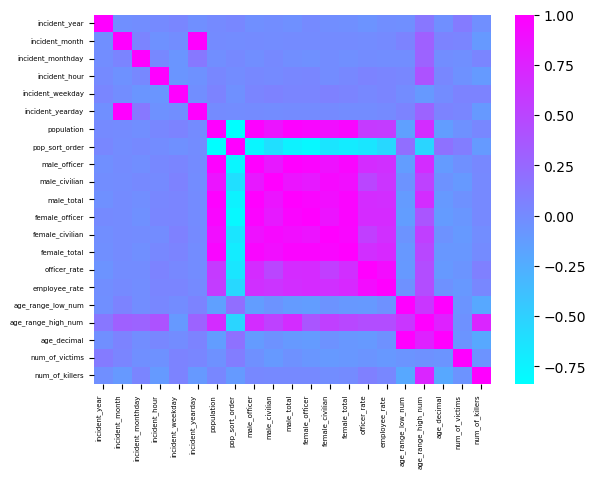

In [392]:
#could use Shapley values if the columns weren't correlated with one-another 

corrmat = X_train.select(nume_cols).to_pandas().corr(method='spearman') #wish polars had this built-in

sns.heatmap(corrmat,cmap='cool',xticklabels=True,yticklabels=True)
plt.xticks(fontsize=5, rotation=90, ha='right')  # x-axis labels
plt.yticks(fontsize=5, rotation=0)                # y-axis labels
plt.show()


The above plot is ugly but it gets the point across: A lot of correlation across numerical columns so Shapley values won't be super informative (categoricals also likely cross correlated; they're ordinally encoded so Spearman correlation wouldn't be super enlightening). Instead, use partial dependence (maybe indiv. cond. expectation)

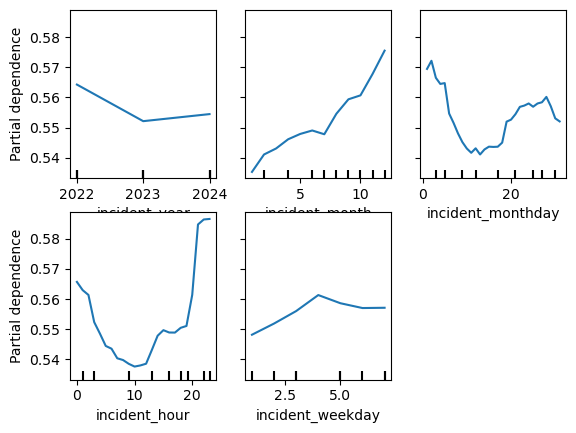

In [495]:
PartialDependenceDisplay.from_estimator(bignmodel.best_estimator_,
                                        X_holdout.to_pandas(),
                                        nume_cols[0:5]
                                        #centered=True
                                        )

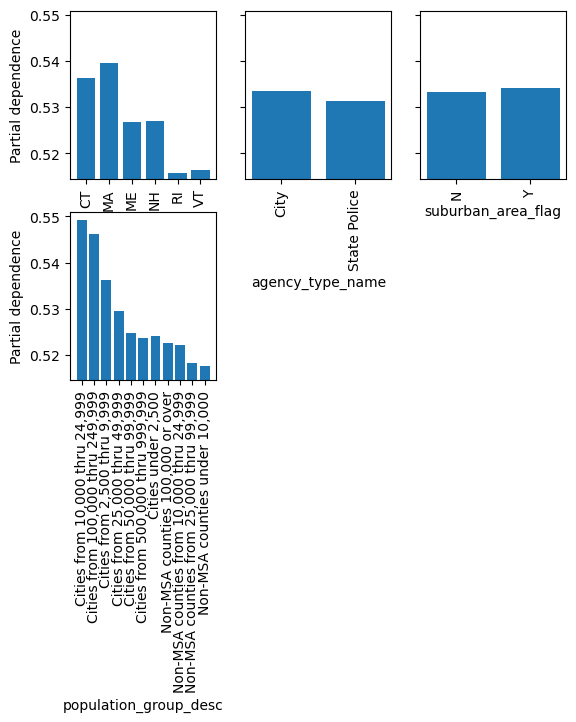

In [378]:

PartialDependenceDisplay.from_estimator(bignmodel.best_estimator_,
                                        X_holdout.to_pandas(),
                                        cate_cols[1:5],
                                        categorical_features = cate_cols[1:5]
                                        #centered=True
                                        )


In [ ]:
#unreasonable to look at ALL of the plots for all of the variables (even if they weren't ugly). Let's just pull the partial dependency curves out and find the optimal
#value of each independent variable such that (on average) the probability of getting away with murder is maximized/minimized

optimal_values = {}
anti_optimal_values = {}

for variable in X_holdout.drop(['resident_status_code','criminal_act_name']).columns: #have to drop these two columns because partial_dependence can't handle nulls in cat-columns
    pdep = partial_dependence(bignmodel.best_estimator_,
                    X_holdout.to_pandas(),
                    [variable] ,
                    categorical_features = cate_cols,
                    feature_names= X_holdout.columns
                    )
    maxindex = np.argmax(pdep['average'])
    minindex = np.argmin(pdep['average'])
    optimal_values[variable] = pdep['grid_values'][0][maxindex], pdep['average'][0][maxindex] 
    anti_optimal_values[variable] = pdep['grid_values'][0][minindex], pdep['average'][0][minindex]
    print(f"best chance: {variable},{optimal_values[variable]}")
    print(f"worst chance: {variable},{anti_optimal_values[variable]}")

The above list of partial dependencies is not very illuminating; the probability-deltas are rarely more than a couple percentage points and they're mostly centered around .55 
Presumably, the averaged nature of the PDs is hiding complex relationships between variables-- this is evidenced by the model's output below: many predicted-probs of scot-freedom at the extremes.

In [ ]:
bignmodel.best_estimator_.predict_proba(X_holdout)


Best bet: a utility that takes info about a murder from the user and spits out the chances of the killer getting away with it.

Should train a new model with some of the columns removed, based on the lessons from the exploratory anaysis above. 

In [521]:
nume_cols

['incident_month',
 'incident_monthday',
 'incident_hour',
 'incident_weekday',
 'incident_yearday',
 'report_date_flag',
 'age_range_low_num',
 'age_range_high_num',
 'age_decimal',
 'prop_destruction',
 'taken_by_cops',
 'looted_remains',
 'firearms',
 'feet_and_fists',
 'edged_weapon',
 'vehicle_as_weapon',
 'blunt_weapon',
 'weaponized_fire',
 'weapons_unknown',
 'choked_or_strangled',
 'poison',
 'other_weapon',
 'num_of_victims',
 'num_of_killers',
 'resident_status_code_is_null',
 'criminal_act_name_is_null']

In [525]:
# we will drop incident_year as it is not helpful for predicting future events.
Xadj = X.drop(['incident_year','agency_type_name','population','population_group_desc','pop_sort_order',
                'male_officer','male_civilian','male_total','female_officer','female_civilian','female_total',
                'officer_rate','employee_rate','population_is_null','male_officer_is_null','male_civilian_is_null',
                'male_total_is_null','female_officer_is_null','female_civilian_is_null','female_total_is_null',
                'officer_rate_is_null','employee_rate_is_null']) #we will also drop columns outside of the perp's control and columns that are derivative of (or tied to) location

#categorical and numerical columns have changed
cate_cols = [ col for col in Xadj.columns if (Xadj[col].dtype == pl.datatypes.String)]
nume_cols = [ col for col in Xadj.columns if (col not in cate_cols)]

#not dry but who cares?
train_indices, holdout_indices = next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=1).split(Xadj,y,inc_groups)) #resplit the data
Xadj_train, Xadj_holdout = Xadj[train_indices], Xadj[holdout_indices]
y_train, y_holdout = y[train_indices], y[holdout_indices]
inc_groups_train = inc_groups[train_indices]



#Have to re-establish the whole pipeline, irritatingly
nume_trans = Pipeline(steps=[
    ('num_impute', SimpleImputer(strategy='mean')) #try with median and mode too
])

cate_trans = Pipeline(steps=[
    ('cat_impute', SimpleImputer(strategy='constant', fill_value='null_value')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_prepro',  nume_trans, nume_cols ),
    ('cat_prepro', cate_trans, cate_cols )
])

rforest_cal = CalibratedClassifierCV(
    RandomForestClassifier(n_jobs=-1), #have 10 cores, use them
    cv = 5, #could potentially set-up a groupkfold CV scheme here if needed. But for prob-calibration it's probably fine as is
    method = 'isotonic', #try with 'sigmoid' too
    ensemble = True, # False is faster-- change if needed
    n_jobs=-1
)
rforest_pipe = make_pipeline(preprocessor,rforest_cal)


params_grid = { "columntransformer__num_prepro__num_impute__strategy" : ['median'], #['mean','median','most_frequent'],
                "calibratedclassifiercv__method" : ['sigmoid','isotonic'],
                'calibratedclassifiercv__estimator__max_features' : ['sqrt'],
                'calibratedclassifiercv__estimator__n_estimators' : [1000],
                'calibratedclassifiercv__estimator__criterion' : ['gini'], #['gini','log_loss','entropy'],
                'calibratedclassifiercv__estimator__max_depth' : [None,45,20] ,
                'calibratedclassifiercv__estimator__min_samples_split' : [2,5,10]
                } 

halvesearch = HalvingGridSearchCV(
    rforest_pipe,
    params_grid,
    scoring = 'd2_brier_score',
    cv=group_kf, 
    random_state = 1).fit(Xadj_train,y_train,groups=inc_groups_train) 

/Users/zed/miniforge3/envs/scotfree/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['age_range_high_num']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
1.06s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss b

In [527]:
print(halvesearch.best_params_)
print(halvesearch.best_score_)
y_estimate = halvesearch.predict_proba(Xadj_holdout)
d2_brier_score(y_holdout,y_estimate)

{'calibratedclassifiercv__estimator__criterion': 'gini', 'calibratedclassifiercv__estimator__max_depth': 20, 'calibratedclassifiercv__estimator__max_features': 'sqrt', 'calibratedclassifiercv__estimator__min_samples_split': 5, 'calibratedclassifiercv__estimator__n_estimators': 1000, 'calibratedclassifiercv__method': 'sigmoid', 'columntransformer__num_prepro__num_impute__strategy': 'median'}
0.055888818301275275


0.13145065445364146

In [528]:
#god forgive me for the profound wetness of the following code that I've stolen from above
past_n_samples = [1000]
past_d2_briers = [0.05809416020272438]
past_runtimes = [0]
allowedtrainingtime = 2 * 60 * 60 #measured in seconds.
keepgoing = True
adj_bignmodel = None
while keepgoing:
    new_n = past_n_samples[-1] * 2 

    params_grid_adj = {'calibratedclassifiercv__estimator__criterion': ['gini'], 
                   'calibratedclassifiercv__estimator__max_depth': [None], 
                   'calibratedclassifiercv__estimator__max_features': ['sqrt'], 
                   'calibratedclassifiercv__estimator__min_samples_split': [2], 
                   'calibratedclassifiercv__estimator__n_estimators': [new_n], 
                   'calibratedclassifiercv__method': ['sigmoid'], 
                   'columntransformer__num_prepro__num_impute__strategy': ['median']}
    
    start = time.time()
    halvesearchn = HalvingGridSearchCV(
        rforest_pipe,
        params_grid_adj,
        scoring = 'd2_brier_score',
        cv=group_kf,
        random_state = 1).fit(Xadj_train,y_train,groups=inc_groups_train)
    end = time.time()
    
    d2_brier = float(halvesearchn.best_score_)

    runtime = (end - start)//1 #rounding this for readability

    past_n_samples.append(new_n)
    past_d2_briers.append(d2_brier)
    past_runtimes.append(runtime)

    print(f"samples:\t\t{past_n_samples[-1]} \nBSS:\t\t{past_d2_briers[-1]}\nruntime:\t\t{past_runtimes[-1]}")
    if (d2_brier < 1.01 * past_d2_briers[-2]) or sum(past_runtimes) >= allowedtrainingtime: #if the model's d-squared increases by less than 1% after doubling n, call it
        keepgoing = False
        bignmodel = halvesearchn

samples:		2000 
BSS:		0.06235587798171664
runtime:		39.0


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
2.55s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

samples:		4000 
BSS:		0.06241960094624068
runtime:		86.0


This new model scores terribly. Evidently, the columns that I removed are critical to its function (at least with this amount of data). Barring acquisition and loading of more NIBRS data (God help me) we will have to stick with the previous model and ask the user to provide the info. Still, we may be able to remove some of the model's complexity/size with minimal performance loss by removing the unimportant columns.

# Feature Importances

In [113]:
#get variable importances for older better model. Follow sklearn doc's advice and use permutation importance over the built-in impurity strategy

bignmodel = joblib.load("scotfreerandomforestmodel.joblib")

perm_bign = permutation_importance(bignmodel.best_estimator_,X_holdout.to_pandas(),y_holdout,scoring='d2_brier_score',n_repeats=50, n_jobs=-1,random_state=1) # .to_pandas again empirically needed


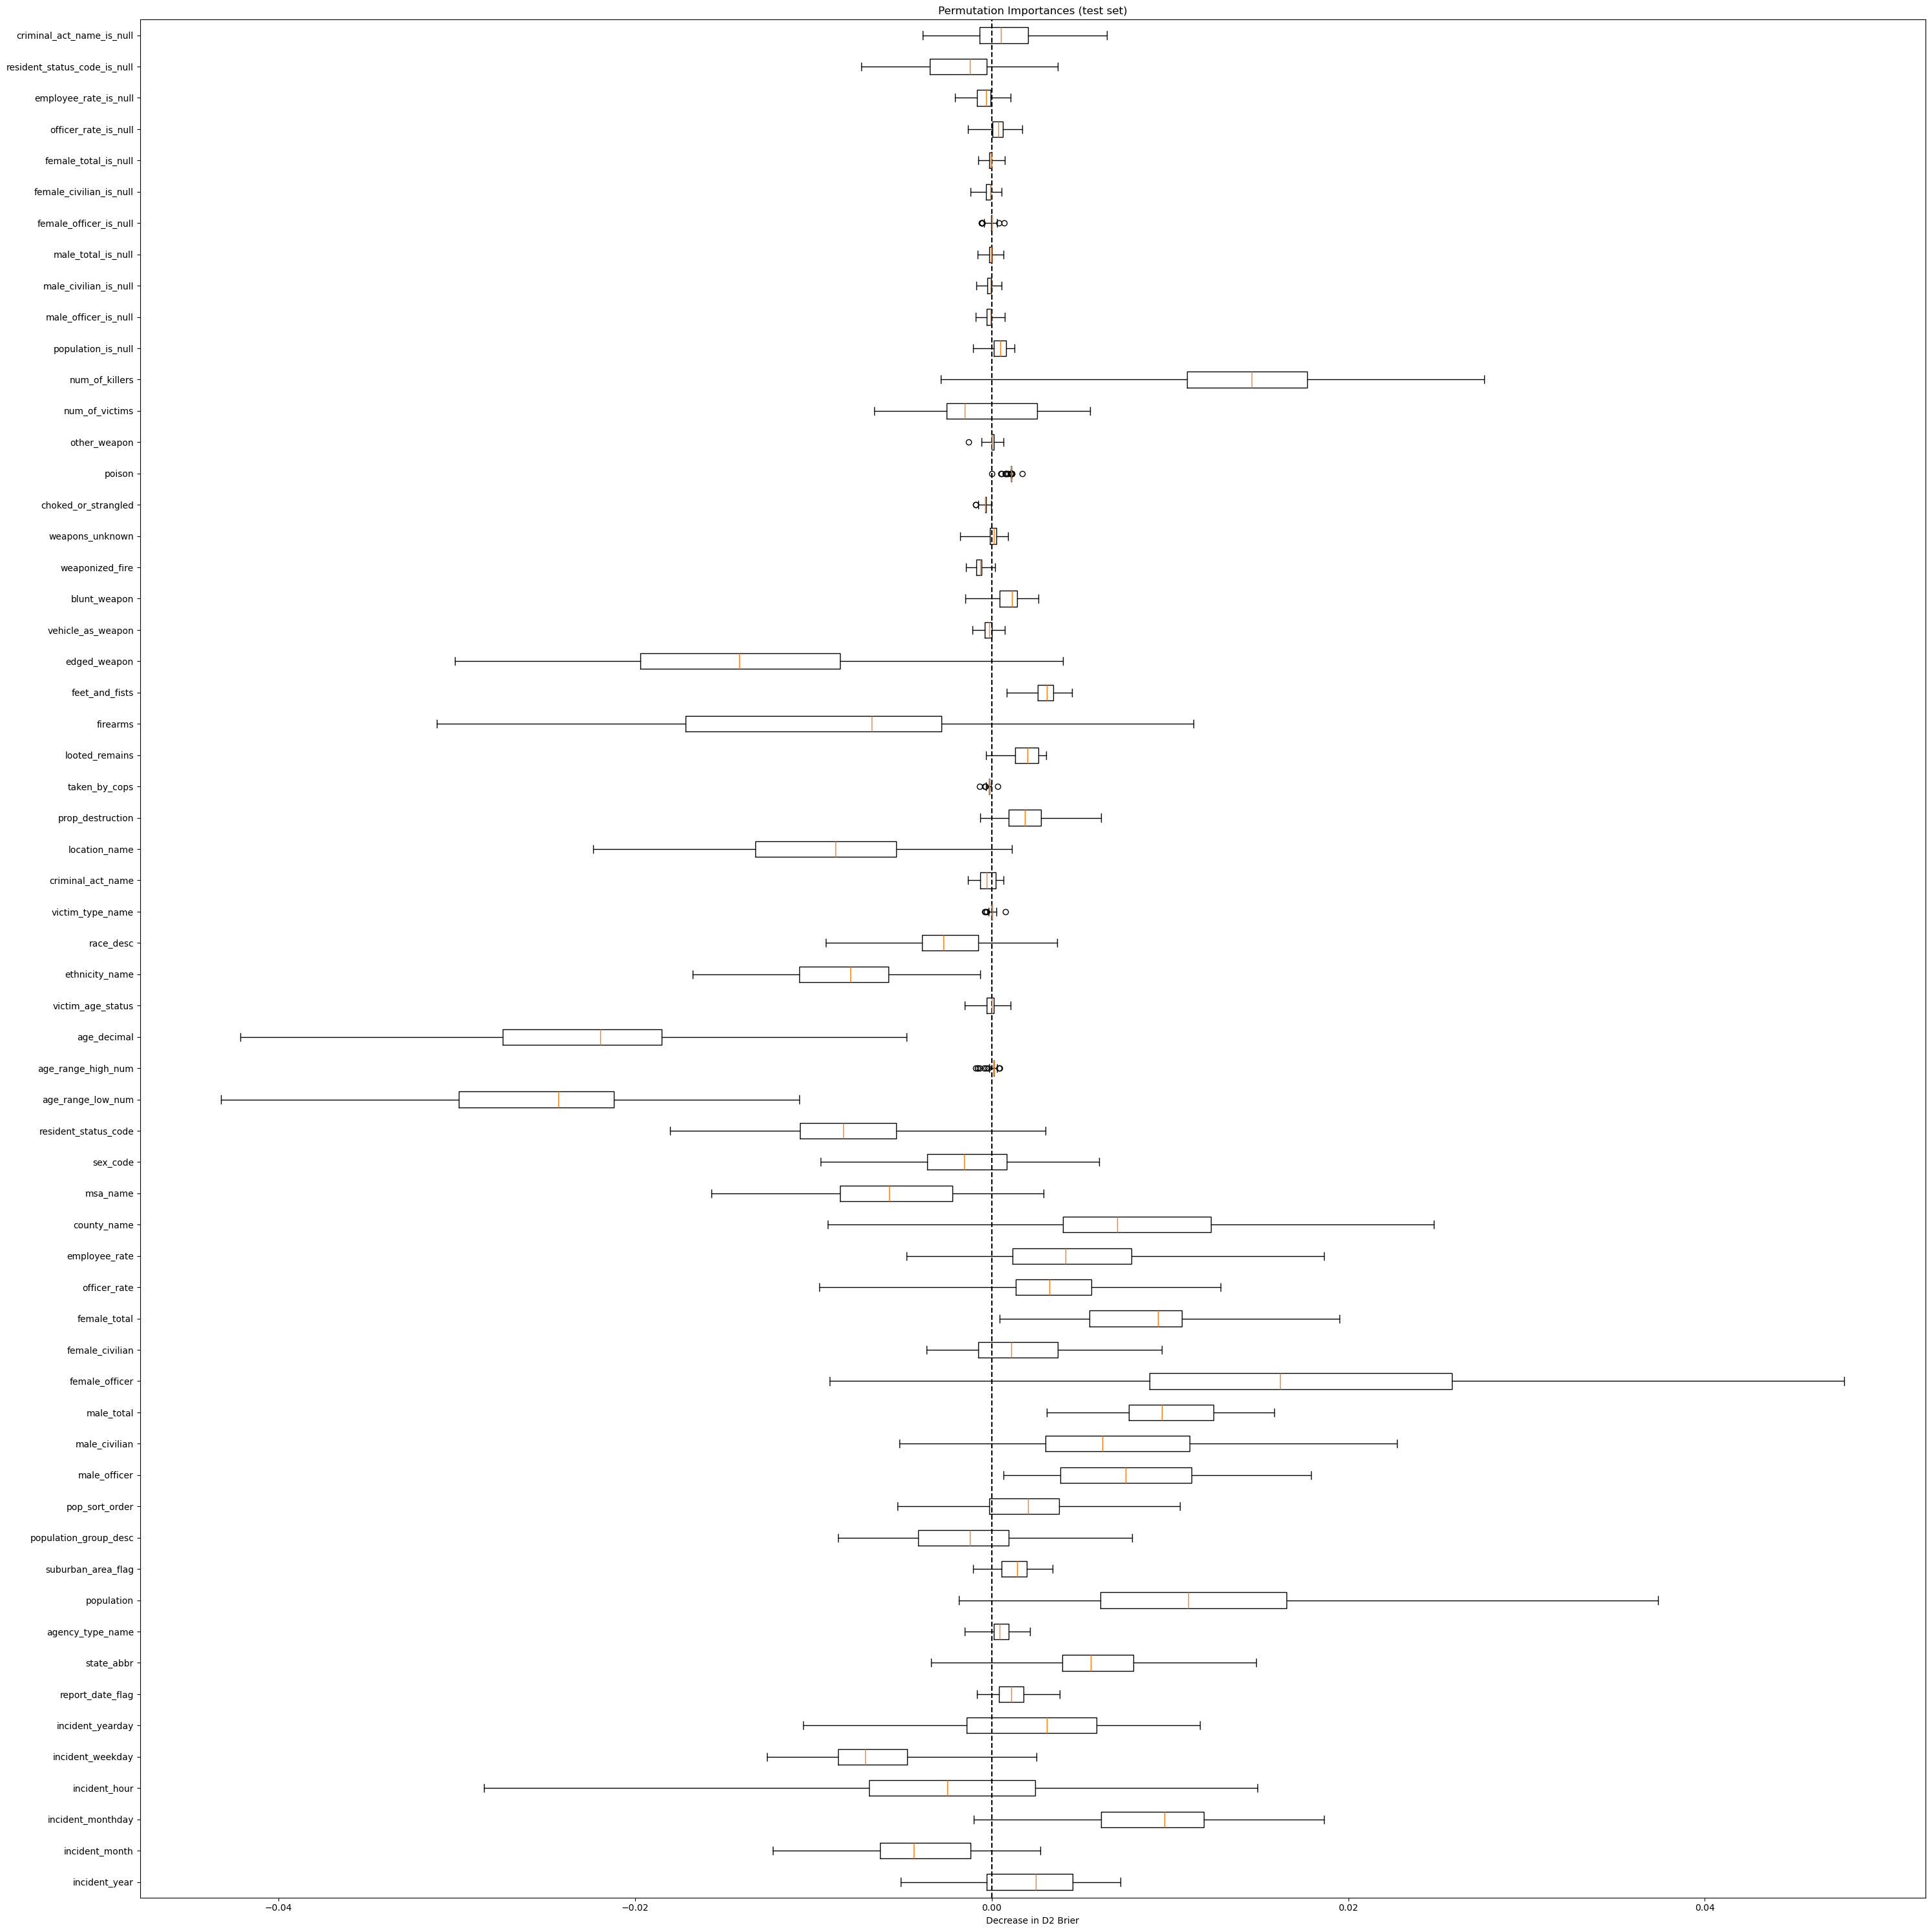

In [68]:
fig, ax = plt.subplots(figsize=[30,30])
ax.boxplot(perm_bign['importances'].T, vert=False, whis=10, tick_labels=X.columns)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in D2 Brier")
fig.tight_layout()
plt.show()

Many columns are useless at best and several are even detrimental to the model's performance (overfit to spurious patterns in the training data, perhaps). Let's remove columns one-by-one, retraining and evaluating as we go, to avoid removing a set of correlated columns that together send a signal.

In [164]:
params = bignmodel.best_params_
rforest_pipe.set_params(**params)
rforest_pipe.set_params(calibratedclassifiercv__estimator__n_estimators=1000) #save some time and fair amount of space. can always up it later

imp_df = pl.DataFrame({
    'feature' : X.columns,
    'importances' : perm_bign['importances'],
    'avg_imps' : perm_bign['importances_mean'],
    'std_imps' : perm_bign['importances_std']
    })
feats_ranked = imp_df.sort(pl.col('avg_imps'))['feature'].to_list()

starting_d2 = d2_brier_score(y_holdout, bignmodel.best_estimator_.predict_proba(X_holdout))



In [165]:


#This is the dataframe that we will cut columns out of
lean_X = X
columns_pruned = []
prune_log = []
sizes = []

for column in feats_ranked:
    lean_X = lean_X.drop(column)
    columns_pruned.append(column)

    lean_cate_cols = [ col for col in lean_X.columns if lean_X[col].dtype == pl.datatypes.String ]
    lean_nume_cols = [ col for col in lean_X.columns if lean_X[col].name not in cate_cols]

    # reuse existing indices from train-holdout split above. We're only removing columns from X
    lean_X_train, lean_X_holdout = lean_X[train_indices], lean_X[holdout_indices]

    #have to update the pipeline with the new values for cate_cols and nume_cols
    rforest_pipe.set_params(columntransformer__transformers = [
        ('num_prepro',  nume_trans, lean_nume_cols ),
        ('cat_prepro', cate_trans, lean_cate_cols )])
    
    #don't know if needed to reset these every time the pipeline is modified-- here for safety
    rforest_pipe.set_params(**params)
    rforest_pipe.set_params(calibratedclassifiercv__estimator__n_estimators=1000)

    lean_model = rforest_pipe.fit(lean_X_train, y_train)
    current_d2 = d2_brier_score(y_holdout, lean_model.predict_proba(X_holdout))

    prune_log.append( (columns_pruned, current_d2) )
    sizes.append( len(pickle.dumps(lean_model)) )
    print(current_d2, columns_pruned)

    if current_d2 < starting_d2:
        break
        
    
    




0.2401999746547211 ['age_range_low_num']
0.2642622829959408 ['age_range_low_num', 'age_decimal']
0.26874578027203777 ['age_range_low_num', 'age_decimal', 'edged_weapon']
0.26303043366596435 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name']
0.26950078927459575 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name', 'firearms']
0.26796348043207296 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name', 'firearms', 'ethnicity_name']
0.27618216618753955 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name', 'firearms', 'ethnicity_name', 'resident_status_code']
0.2696050009438391 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name', 'firearms', 'ethnicity_name', 'resident_status_code', 'incident_weekday']
0.2750217147513063 ['age_range_low_num', 'age_decimal', 'edged_weapon', 'location_name', 'firearms', 'ethnicity_name', 'resident_status_code', 'incident_weekday', 'msa_name']
0.28291982245380376 ['age_range_low_

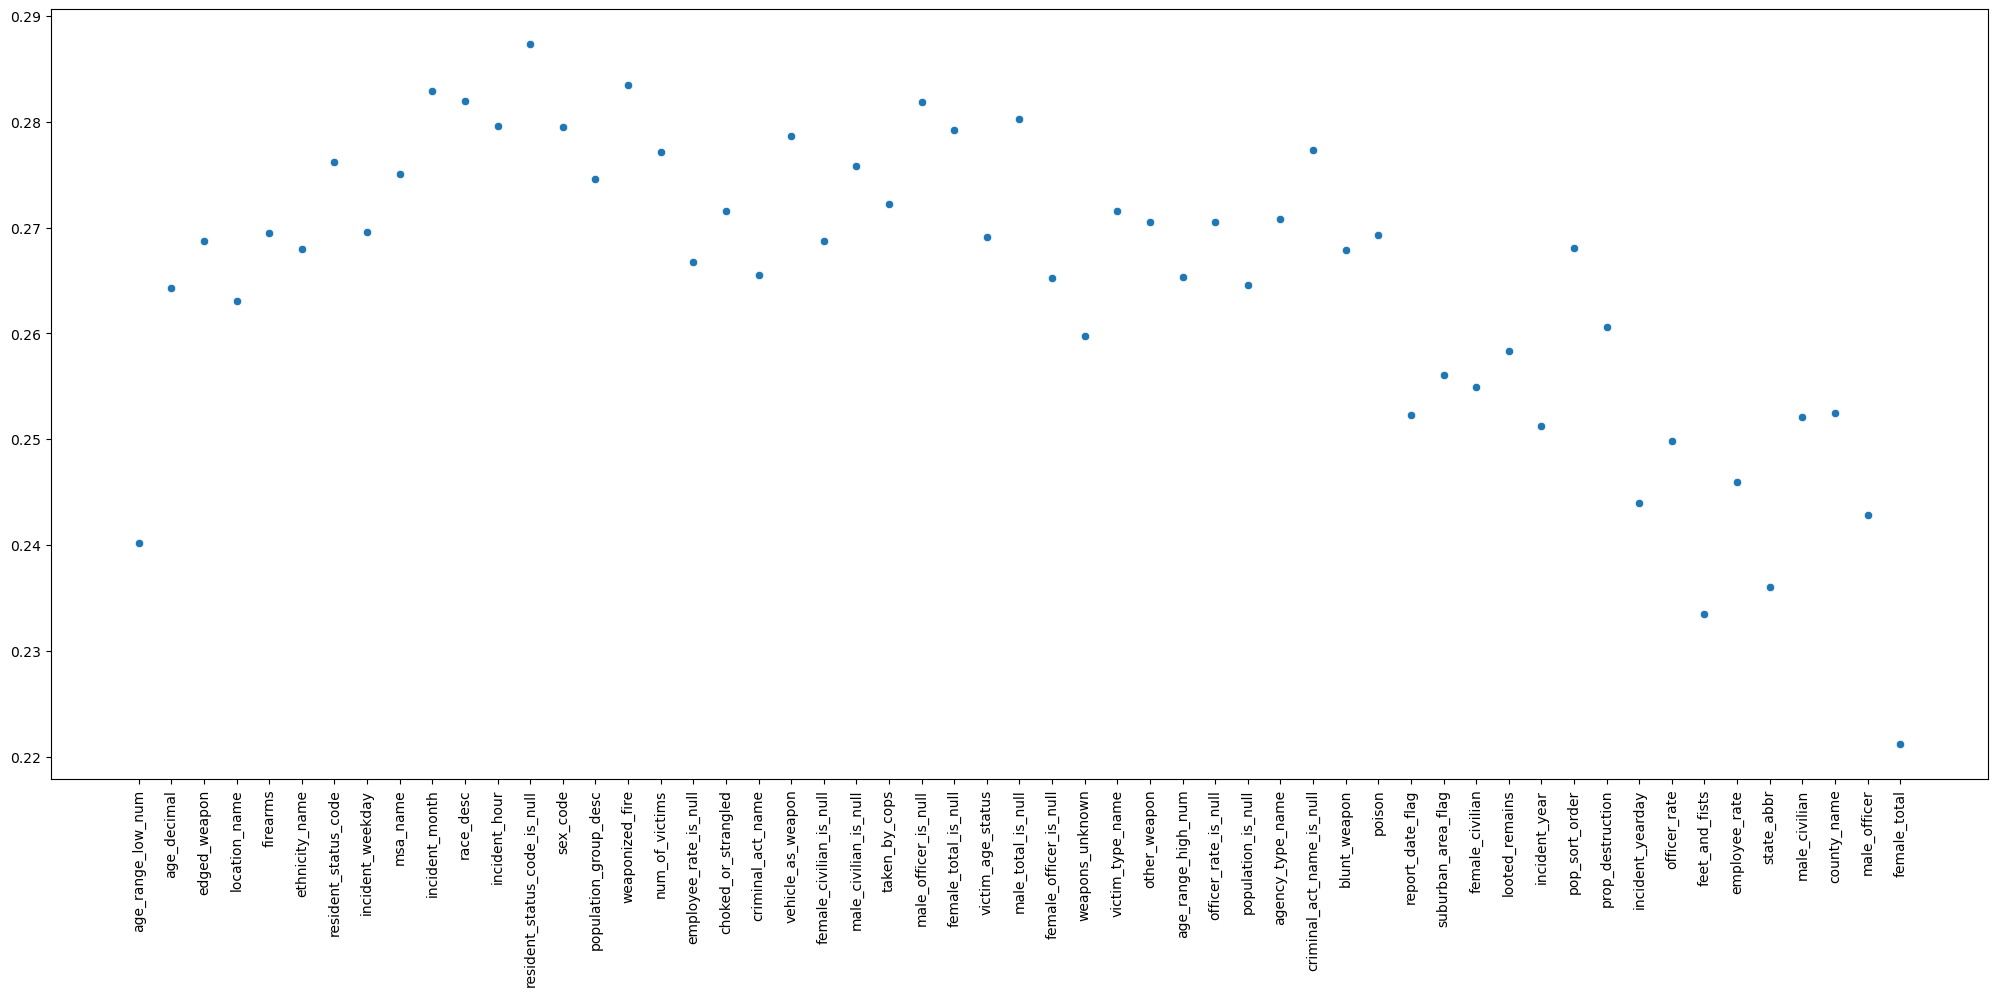

In [166]:
lean_scores = []
for entry in prune_log:
    lean_scores += [entry[1]]

fig, ax = plt.subplots(figsize=[25,10])
sns.scatterplot(x=columns_pruned,y=lean_scores)
ax.tick_params(axis='x', rotation=90)

Excellent result! Removing the worst columns has markedly improved the model. Check for any size improvement as well

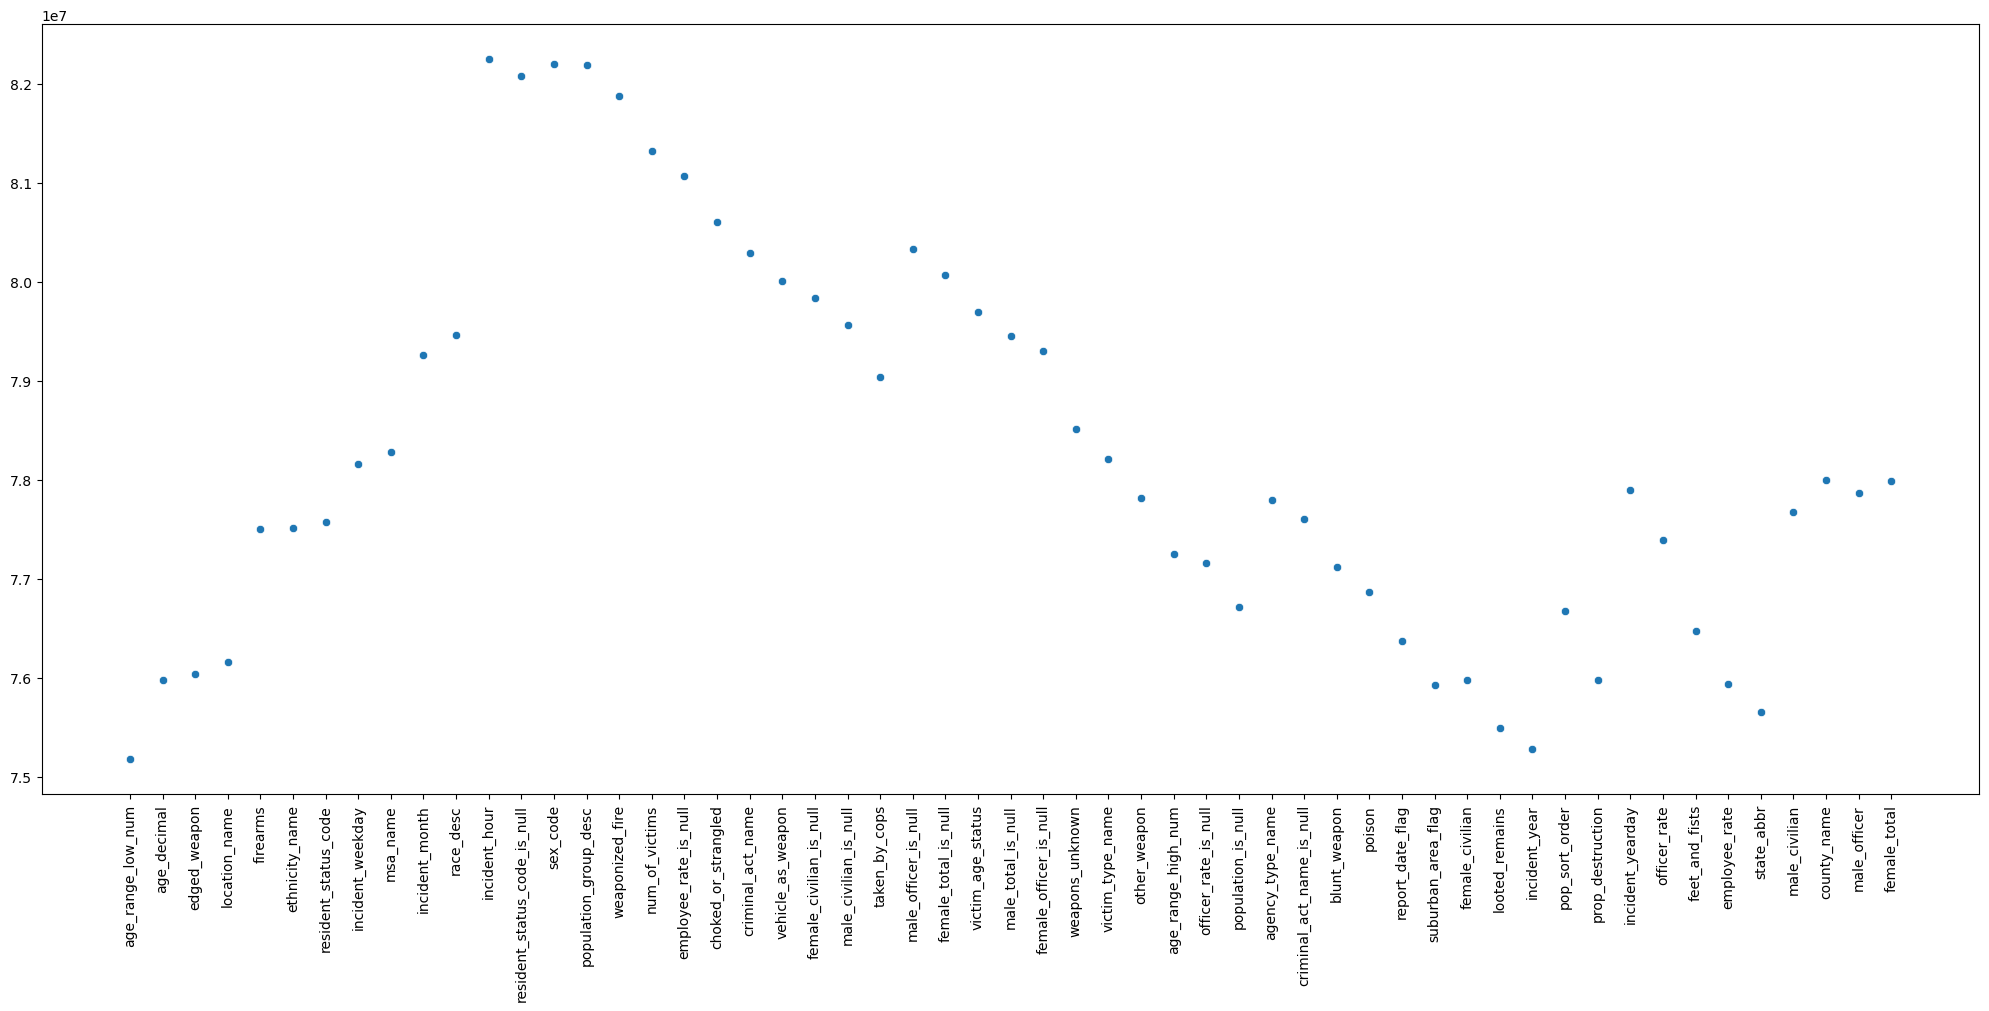

In [167]:

fig, ax = plt.subplots(figsize=[25,10])
sns.scatterplot(x=columns_pruned,y=sizes)
ax.tick_params(axis='x', rotation=90)

Curious that removing the worst columns both improves the model *and* makes it larger. And that after removing sex_code or so both size and performance take on the expected relationship with feature number. Regardless, the model remains unwieldy and scrimping on memory won't make it small enough to matter. We will perform another gridsearch 

In [228]:
columns_pruned[:13]

['age_range_low_num',
 'age_decimal',
 'edged_weapon',
 'location_name',
 'firearms',
 'ethnicity_name',
 'resident_status_code',
 'incident_weekday',
 'msa_name',
 'incident_month',
 'race_desc',
 'incident_hour',
 'resident_status_code_is_null']

In [ ]:

X_thinner = X.drop(columns_pruned[:13]) 
cate_cols_thin = [ col for col in X_thinner.columns if X_thinner[col].dtype == pl.datatypes.String ]
nume_cols_thin = [ col for col in X_thinner.columns if col not in cate_cols_thin]


# same data split technique as before
X_train_thin, X_holdout_thin = X_thinner[train_indices], X_thinner[holdout_indices]
rforest_pipe.set_params(columntransformer__transformers = [
    ('num_prepro',  nume_trans, nume_cols_thin ),
    ('cat_prepro', cate_trans, cate_cols_thin )])

thin_grid = {'calibratedclassifiercv__estimator__criterion': ['gini'],
    'calibratedclassifiercv__estimator__max_depth': [15,20],
    'calibratedclassifiercv__estimator__max_features': ['sqrt', 10, 7],
    'calibratedclassifiercv__estimator__min_samples_split': [10],
    'calibratedclassifiercv__estimator__n_estimators': [500, 700],
    'calibratedclassifiercv__method': ['sigmoid'],
    'columntransformer__num_prepro__num_impute__strategy': ['median']}

group_kf = GroupKFold(n_splits=4)

#retune hyperparams for the reduced column set
thinsearch = GridSearchCV(
    rforest_pipe,
    thin_grid,
    scoring = 'd2_brier_score',
    cv=group_kf).fit(X_train_thin,y_train,groups=inc_groups_train)


In [213]:
print(d2_brier_score(y_holdout,thinsearch.best_estimator_.predict_proba(X_holdout_thin)))
print(thinsearch.best_params_)
print(len(pickle.dumps(thinsearch.best_estimator_))/1000000)
print(f"The old model is {len(pickle.dumps(bignmodel))/1048576} MB")



0.2754287977838348
{'calibratedclassifiercv__estimator__criterion': 'gini', 'calibratedclassifiercv__estimator__max_depth': 15, 'calibratedclassifiercv__estimator__max_features': 10, 'calibratedclassifiercv__estimator__min_samples_split': 10, 'calibratedclassifiercv__estimator__n_estimators': 700, 'calibratedclassifiercv__method': 'sigmoid', 'columntransformer__num_prepro__num_impute__strategy': 'median'}
53.529783
The old model is 142.48975372314453 MB


New model is smaller and performs better after variable reduction. Use it for the web-app

In [ ]:
thinmodel = thinsearch.best_estimator_
joblib.dump(thinmodel, "scotfreerandomforestmodel.joblib", protocol=5)

['scotfreerandomforestmodel.joblib']

Web-app also needs a repository of agencies and their statistics

In [ ]:
#this cell provides agencies list for the interactive-agency-choice function of the web-app
postgres_uri = ""
agency_query = """
select 
    age.yearly_agency_id,
    age.data_year,
    age.ucr_agency_name,
	age.ncic_agency_name, age.pub_agency_name,age.pub_agency_unit,
	age.state_abbr,age.agency_type_name,age.population, age.suburban_area_flag,
	age.population_group_desc,age.pop_sort_order, 
	age.male_officer, age.male_civilian, age.male_total, age.female_officer,
	age.female_civilian, age.female_total, age.officer_rate, age.employee_rate, --*_rate columns are per/1000 citizens
	age.county_name, age.msa_name 
    from agencies as age
    --where age.data_year = 2024
    """

agencies = pl.read_database_uri(agency_query,postgres_uri)

#set the 0 population and derivative columns to null
agencies = agencies.with_columns(
    (   pl.when(  pl.col('population') == 0  ).then(None).otherwise(pl.col('population')).alias('population') ),
    (   pl.when(  (pl.col('population') == 0) & (pl.col('officer_rate') == 0)  ).then(None).otherwise(pl.col('officer_rate')).alias('officer_rate') ),
    (   pl.when(  (pl.col('population') == 0) & (pl.col('employee_rate') == 0)  ).then(None).otherwise(pl.col('employee_rate')).alias('employee_rate') )
)

agencies.write_parquet(f"agencies.parquet")

NameError: name 'scikit' is not defined